In [24]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle, ConnectionPatch

In [33]:
nerfacto_img_path = Path("../outputs/plot_461/nerfacto/2025-03-09_213152/test/rgb/FPWW036_SR0461_FIP2_cam_12.jpg")
splatfacto_img_path = Path("../outputs/nerfstudio/splatfacto/2025-03-11_210405/test/rgb/FPWW036_SR0461_FIP2_cam_12.jpg")

In [34]:
# Load the images
img1 = plt.imread(nerfacto_img_path)  # Replace with your image paths
img2 = plt.imread(splatfacto_img_path)  

In [35]:
img1.shape

(2996, 4095, 3)

ValueError: zero-size array to reduction operation minimum which has no identity

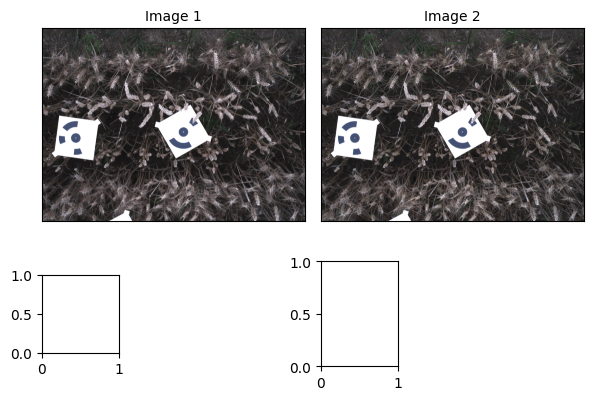

In [38]:
# Define zoom regions - distributed around different areas of the image
# zoom_regions = [
#     {'x': 1000, 'y': 80, 'w': 100, 'h': 100},     # Top-left region
#     {'x': 200, 'y': 150, 'w': 100, 'h': 100},   # Center region
#     {'x': 300, 'y': 220, 'w': 100, 'h': 100}    # Bottom-right region
# ]
zoom_regions = [
    {'x': 2239, 'y': 3282, 'w': 389, 'h': 644},    # Wheat Head 73
    {'x': 909, 'y': 752, 'w': 389, 'h': 615},    # Wheat Head 11
    {'x': 1585, 'y': 976, 'w': 373, 'h': 467}     # Wheat Head 43
]

# Create a figure with horizontal layout
fig = plt.figure(figsize=(7, 4.5))  # Wider for horizontal layout

# Create grid layout - images side by side, zooms below
gs = GridSpec(2, 6, figure=fig, height_ratios=[2, 1])

# Main images
ax1 = fig.add_subplot(gs[0, 0:3])  # Image 1 takes left half
ax2 = fig.add_subplot(gs[0, 3:6])  # Image 2 takes right half

# Display main images
ax1.imshow(img1)
ax1.set_title('Image 1', fontsize=10)
ax1.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False,
                labelbottom=False, labelleft=False)

ax2.imshow(img2)
ax2.set_title('Image 2', fontsize=10)
ax2.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False,
                labelbottom=False, labelleft=False)

# Distinct colors for each zoom region
colors = ['#FF4136', '#2ECC40', '#0074D9']  # Red, Green, Blue

# Add zoom regions and create insets
for i, region in enumerate(zoom_regions):
    x, y, w, h = region['x'], region['y'], region['w'], region['h']
    color = colors[i]
    
    # Add rectangles to both main images
    rect1 = Rectangle((x, y), w, h, linewidth=1.5, edgecolor=color, facecolor='none')
    rect2 = Rectangle((x, y), w, h, linewidth=1.5, edgecolor=color, facecolor='none')
    ax1.add_patch(rect1)
    ax2.add_patch(rect2)
    
    # Position for zooms - 3 zoom columns for each image
    ax_zoom1 = fig.add_subplot(gs[1, i])         # Image 1 zooms
    ax_zoom2 = fig.add_subplot(gs[1, i+3])       # Image 2 zooms
    
    # Make sure we don't go out of bounds
    h_adj1, w_adj1 = min(h, img1.shape[0]-y), min(w, img1.shape[1]-x)
    h_adj2, w_adj2 = min(h, img2.shape[0]-y), min(w, img2.shape[1]-x)
    
    # Display zoomed regions
    ax_zoom1.imshow(img1[y:y+h_adj1, x:x+w_adj1])
    ax_zoom1.set_title(f"{i+1}", fontsize=8)
    ax_zoom1.tick_params(axis='both', which='both', bottom=False, top=False, 
                       left=False, right=False, labelbottom=False, labelleft=False)
    
    ax_zoom2.imshow(img2[y:y+h_adj2, x:x+w_adj2])
    ax_zoom2.set_title(f"{i+1}", fontsize=8)
    ax_zoom2.tick_params(axis='both', which='both', bottom=False, top=False, 
                       left=False, right=False, labelbottom=False, labelleft=False)
    
    # Color the borders to match the region markers
    for ax in [ax_zoom1, ax_zoom2]:
        for spine in ax.spines.values():
            spine.set_color(color)
            spine.set_linewidth(2)

plt.tight_layout()

# Save the figure
# plt.savefig('wheat_comparison_horizontal.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('wheat_comparison_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()

# # For LaTeX two-column format, make sure this uses figure* environment
# # Here's a version resized specifically for two-column format
# fig_twocol = plt.figure(figsize=(6.5, 3.5))  # Width for two-column journal
# gs_twocol = GridSpec(2, 6, figure=fig_twocol, height_ratios=[2, 1])

# # Same code as above but with adjusted figure size and fonts
# # ... (repeat the code above with fig_twocol and gs_twocol)

# plt.tight_layout()
# plt.savefig('wheat_comparison_twocolumn.pdf', dpi=300, bbox_inches='tight')

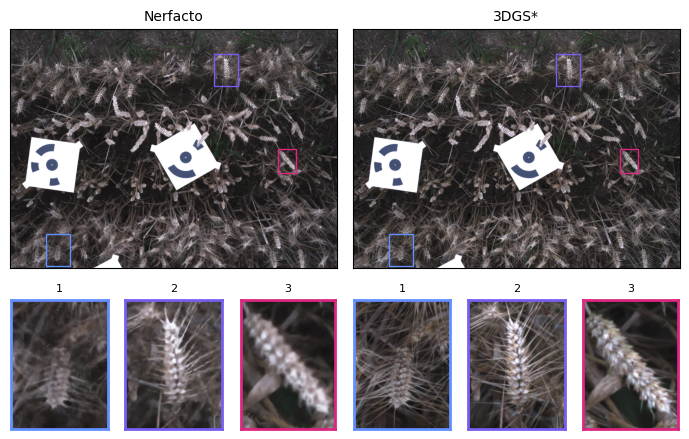

In [64]:
zoom_regions = [
    {'x': 450, 'y': 2570, 'w': 300, 'h': 400} , 
    {'x': 2550, 'y': 320, 'w': 300, 'h': 400},  
    {'x': 3350, 'y': 1500, 'w': 220, 'h': 300}
]

# Create a figure with horizontal layout
fig = plt.figure(figsize=(7, 4.5))

# Create grid layout - images side by side, zooms below
gs = GridSpec(2, 6, figure=fig, height_ratios=[2, 1])

# Main images
ax1 = fig.add_subplot(gs[0, 0:3])  # Image 1 takes left half
ax2 = fig.add_subplot(gs[0, 3:6])  # Image 2 takes right half

# Display main images
ax1.imshow(img1)
ax1.set_title('Nerfacto', fontsize=10)
ax1.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

ax2.imshow(img2)
ax2.set_title('3DGS*', fontsize=10)
ax2.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False,
                labelbottom=False, labelleft=False)

# Distinct colors for each zoom region
#colors = ['#FF4136', '#2ECC40', '#0074D9']  # Red, Green, Blue
colors = ['#648FFF', '#785EF0', '#DC267F']  # Blue, Purple, Magenta

# Add zoom regions and create insets
for i, region in enumerate(zoom_regions):
    x, y, w, h = region['x'], region['y'], region['w'], region['h']
    color = colors[i]
    
    # Make sure coordinates are within image bounds
    height, width = img1.shape[:2]
    x = min(max(0, x), width - 10)
    y = min(max(0, y), height - 10)
    w = min(w, width - x)
    h = min(h, height - y)
    
    # Add rectangles to both main images
    rect1 = Rectangle((x, y), w, h, linewidth=1, edgecolor=color, facecolor='none')
    rect2 = Rectangle((x, y), w, h, linewidth=1, edgecolor=color, facecolor='none')
    ax1.add_patch(rect1)
    ax2.add_patch(rect2)
    
    # Position for zooms - 3 zoom columns for each image
    ax_zoom1 = fig.add_subplot(gs[1, i])         # Image 1 zooms
    ax_zoom2 = fig.add_subplot(gs[1, i+3])       # Image 2 zooms
    
    # Make sure we don't go out of bounds
    h_adj1, w_adj1 = min(h, img1.shape[0]-y), min(w, img1.shape[1]-x)
    h_adj2, w_adj2 = min(h, img2.shape[0]-y), min(w, img2.shape[1]-x)
    
    # Display zoomed regions
    ax_zoom1.imshow(img1[y:y+h_adj1, x:x+w_adj1])
    ax_zoom1.set_title(f"{i+1}", fontsize=8)
    ax_zoom1.tick_params(axis='both', which='both', bottom=False, top=False, 
                       left=False, right=False, labelbottom=False, labelleft=False)
    
    ax_zoom2.imshow(img2[y:y+h_adj2, x:x+w_adj2])
    ax_zoom2.set_title(f"{i+1}", fontsize=8)
    ax_zoom2.tick_params(axis='both', which='both', bottom=False, top=False, 
                       left=False, right=False, labelbottom=False, labelleft=False)
    
    # Color the borders to match the region markers
    for ax in [ax_zoom1, ax_zoom2]:
        for spine in ax.spines.values():
            spine.set_color(color)
            spine.set_linewidth(2)

# # Add a legend explaining the numbered zooms
# legend_text = "\n".join([f"{i+1}: {label}" for i, label in enumerate(zoom_labels)])
# fig.text(0.01, 0.02, legend_text, fontsize=8)

plt.tight_layout()

# Save the figure
plt.savefig('wheat_heads_comparison.pdf', dpi=300, bbox_inches='tight')
plt.savefig('wheat_heads_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Wheat head 1 at (127.5, 970.7). Width: 119.0, Height: 216.5
Wheat head 2 at (65.2, 824.1). Width: 119.0, Height: 90.8
Wheat head 3 at (320.2, 495.8). Width: 102.0, Height: 181.6
Wheat head 4 at (311.7, 852.0). Width: 107.7, Height: 139.7
Wheat head 5 at (632.0, 492.4). Width: 158.7, Height: 146.7
Wheat head 6 at (525.7, 584.9). Width: 155.9, Height: 129.2
Wheat head 7 at (721.2, 852.0). Width: 167.2, Height: 223.5
Wheat head 8 at (905.4, 780.4). Width: 138.9, Height: 150.2
Wheat head 9 at (1139.2, 838.0). Width: 164.4, Height: 244.4
Wheat head 10 at (1323.4, 967.2). Width: 119.0, Height: 293.3
Wheat head 11 at (1509.1, 775.2). Width: 121.9, Height: 230.5
Wheat head 12 at (1451.0, 483.6). Width: 141.7, Height: 192.1
Wheat head 13 at (2183.5, 508.1). Width: 121.9, Height: 143.2
Wheat head 14 at (2703.6, 515.0). Width: 113.4, Height: 268.9
Wheat head 15 at (2496.7, 501.1). Width: 181.4, Height: 122.2
Wheat head 16 at (3361.0, 460.9). Width: 107.7, Height: 209.5
Wheat head 17 at (3339.8, 7

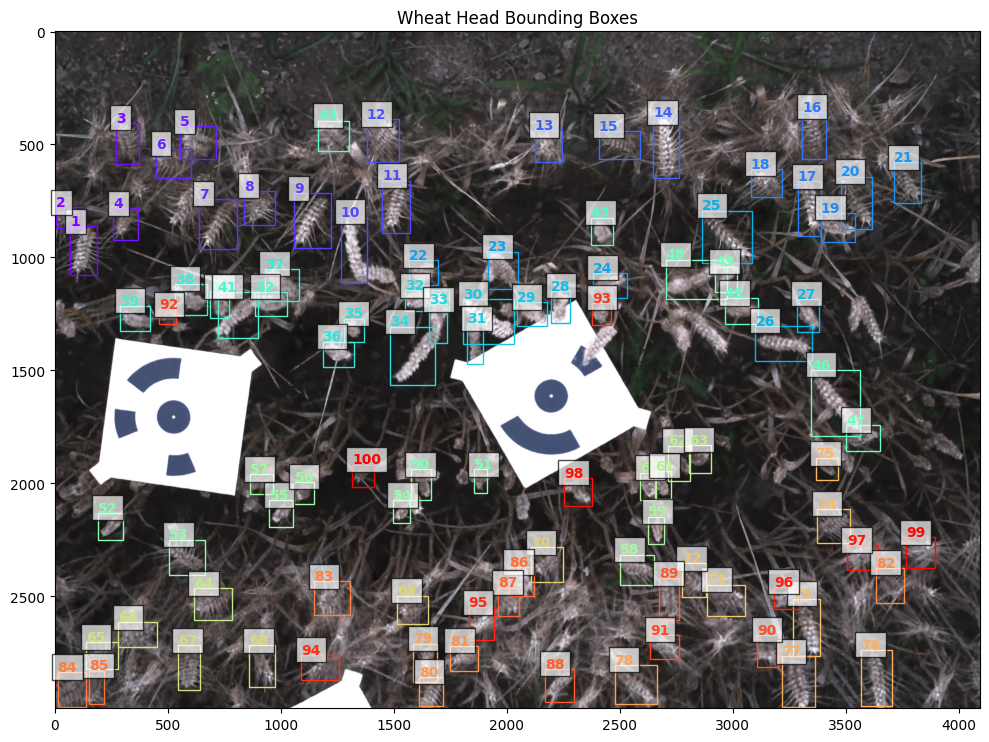

In [63]:
bboxes_path = Path('../dataset/bboxes_test/FPWW036_SR0461_FIP2_cam_12.txt')

# Parse the bounding box data
bbox_data = []
with open(bboxes_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 5:  # Format: class x_center y_center width height
            class_id, x_center, y_center, width, height = parts
            bbox_data.append({
                'class_id': int(class_id),
                'x_center': float(x_center),
                'y_center': float(y_center),
                'width': float(width),
                'height': float(height)
            })

# Create figure and axis
fig, ax = plt.subplots(1, figsize=(10, 8))

# Display the image
ax.imshow(img1)

# Get image dimensions
img_height, img_width = img1.shape[:2]

# Limit the number of boxes to display to avoid overcrowding
max_boxes = 100  # You can adjust this
displayed_boxes = min(len(bbox_data), max_boxes)

# Colors for the boxes
colors = plt.cm.rainbow(np.linspace(0, 1, displayed_boxes))

# Add bounding boxes with numbers
for i in range(displayed_boxes):
    box = bbox_data[i]
    
    # Convert normalized coordinates to pixel coordinates
    x_center = box['x_center'] * img_width
    y_center = box['y_center'] * img_height
    box_width = box['width'] * img_width
    box_height = box['height'] * img_height
    
    # Calculate top-left corner from center, width, height
    x = x_center - box_width/2
    y = y_center - box_height/2
    
    # Create a rectangle patch
    rect = patches.Rectangle((x, y), box_width, box_height, 
                            linewidth=1, edgecolor=colors[i], 
                            facecolor='none')
    
    # Add the rectangle to the plot
    ax.add_patch(rect)
    
    # Add a number label
    print(f'Wheat head {i+1} at ({x_center:.1f}, {y_center:.1f}). Width: {box_width:.1f}, Height: {box_height:.1f}')
    ax.text(x, y-5, str(i+1), color=colors[i], fontsize=10, 
            fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))

ax.set_title('Wheat Head Bounding Boxes')
#ax.axis('off')  # Turn off axis

plt.tight_layout()
# plt.savefig('wheat_heads_numbered.png', dpi=300, bbox_inches='tight')
# plt.savefig('wheat_heads_numbered.pdf', dpi=300, bbox_inches='tight')
plt.show()

# # Create a second visualization with fewer boxes for clearer viewing
# fig2, ax2 = plt.subplots(1, figsize=(10, 8))
# ax2.imshow(img1)

# # Select a smaller subset - every 10th box
# subset_indices = range(0, len(bbox_data), 10)
# subset_colors = plt.cm.rainbow(np.linspace(0, 1, len(subset_indices)))

# for idx, i in enumerate(subset_indices):
#     if i >= len(bbox_data):
#         break
        
#     box = bbox_data[i]
    
#     # Convert normalized coordinates to pixel coordinates
#     x_center = box['x_center'] * img_width
#     y_center = box['y_center'] * img_height
#     box_width = box['width'] * img_width
#     box_height = box['height'] * img_height
    
#     # Calculate top-left corner from center, width, height
#     x = x_center - box_width/2
#     y = y_center - box_height/2
    
#     # Create a rectangle patch - thicker lines for better visibility
#     rect = patches.Rectangle((x, y), box_width, box_height, 
#                             linewidth=2.5, edgecolor=subset_colors[idx], 
#                             facecolor='none')
    
#     # Add the rectangle to the plot
#     ax2.add_patch(rect)
    
#     # Add a larger number label
#     ax2.text(x, y-8, str(i+1), color=subset_colors[idx], fontsize=12, 
#             fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))

# ax2.set_title('Selected Wheat Head Bounding Boxes')
# ax2.axis('off')  # Turn off axis

# plt.tight_layout()
# # plt.savefig('wheat_heads_selected.png', dpi=300, bbox_inches='tight')
# # plt.savefig('wheat_heads_selected.pdf', dpi=300, bbox_inches='tight')
# plt.show()